---
title: "Inverse & pseudoinverse"
categories: []
---

This chapter climbs a ladder of invertibility. At the top sits the true inverse, defined only for square, full-rank matrices. One rung down sit the one-sided inverses, which salvage invertibility for tall and wide matrices. At the bottom is the Moore–Penrose pseudoinverse, which exists for every matrix and collapses into the other rungs whenever they are available. The SVD does the heavy lifting throughout: every inverse on this ladder is a recipe built from the singular values, and the pseudoinverse is simply the matrix obtained by inverting the *nonzero* singular values and leaving the zero ones at zero.


## The invertible case

For a square matrix $\mathbf{A} \in \mathbb{R}^{n\times n}$ the following statements are equivalent.

$$
\mathbf{A} \text{ invertible}
\;\Longleftrightarrow\;
\operatorname{rank} \mathbf{A} = n
\;\Longleftrightarrow\;
\sigma_n > 0
\;\Longleftrightarrow\;
\det \mathbf{A} \neq 0 .
$$

The middle equivalences were established in Chapters 4 and 5; the last pair connects to Chapter 5. The point worth carrying forward is the *SVD formula for the inverse*. If $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ with every $\sigma_i > 0$, then $\boldsymbol{\Sigma}$ is invertible with $\boldsymbol{\Sigma}^{-1} = \operatorname{diag}(\sigma_1^{-1},\dots,\sigma_n^{-1})$, so

$$
\boxed{\mathbf{A}^{-1}
= \mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{U}^{\mathsf T}
= \sum_{i=1}^{n} \sigma_i^{-1}\, \mathbf{v}_i \mathbf{u}_i^{\mathsf T} .}
$$

The check is one line: $\mathbf{A}\mathbf{A}^{-1} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}\mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{U}^{\mathsf T} = \mathbf{U}\mathbf{I}\mathbf{U}^{\mathsf T} = \mathbf{I}$. Inverting a diagonal matrix is just taking reciprocals, and rotating to the singular-vector basis does the rest. The formula also reveals the singular values of the inverse: they are $\sigma_n^{-1} \ge \cdots \ge \sigma_1^{-1}$, the same numbers *in reverse order*, so $\lVert\mathbf{A}^{-1}\rVert_2 = 1/\sigma_n$.


**Inverting through the SVD.** The following reconstructs $\mathbf{A}^{-1}$ from $\mathbf{U}, \boldsymbol{\Sigma}, \mathbf{V}$ and compares it against NumPy's built-in inverse.


In [1]:
from watchtower.core import set_format
set_format("svg")


In [2]:
import numpy as np

rng = np.random.default_rng(0)
n = 5
A = rng.standard_normal((n, n))
A = A @ A.T + n * np.eye(n)          # symmetric positive definite -> invertible, well-conditioned

U, s, Vt = np.linalg.svd(A)
Ainv_svd = (Vt.T / s) @ U.T          # V diag(1/sigma) U^T

print("|| A Ainv_svd - I ||  =", np.linalg.norm(A @ Ainv_svd - np.eye(n)))
print("|| Ainv_svd - inv(A) || =", np.linalg.norm(Ainv_svd - np.linalg.inv(A)))
print("singular values of A^-1 (descending):", np.sort(1.0 / s)[::-1])


|| A Ainv_svd - I ||  = 1.145890456092369e-15
|| Ainv_svd - inv(A) || = 1.3844034850269233e-16
singular values of A^-1 (descending): [0.19561687 0.19073547 0.11950802 0.08609511 0.07645656]


The two routes agree to machine precision. The last line confirms the order-reversal: the largest singular value of $\mathbf{A}^{-1}$ is the reciprocal of the *smallest* singular value of $\mathbf{A}$. That single number is the amplification factor when solving $\mathbf{A}\mathbf{x}=\mathbf{b}$, the seed of the condition-number discussion that follows.


## Never form the inverse

The formula $\mathbf{A}^{-1} = \mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{U}^{\mathsf T}$ is for *reasoning*, not for computing. Numerically, forming the inverse explicitly is almost never right; instead, solve the linear system $\mathbf{A}\mathbf{x} = \mathbf{b}$ directly. Three reasons.

(1) **Cost.** Solving $\mathbf{A}\mathbf{x}=\mathbf{b}$ with an LU factorization and back-substitution costs about $\tfrac{2}{3}n^3$ floating-point operations. Forming $\mathbf{A}^{-1}$ costs $\tfrac{8}{3}n^3$ (the $\tfrac{2}{3}n^3$ factorization plus $2n^3$ to invert the triangular factors), and the final multiply adds $2n^2$; the inverse route does roughly four times the work.

(2) **Sparsity.** An inverse is dense even when the original matrix is sparse. A matrix with a handful of nonzeros per row can have an inverse with no zeros at all, blowing up memory from $O(n)$ to $O(n^2)$.

(3) **Accuracy.** Solving computes a backward-stable answer directly; forming the inverse and multiplying compounds rounding error and can be unstable for ill-conditioned matrices.


**Sparse in, dense out.** A diagonally dominant matrix with three off-diagonal nonzeros per row, yet an inverse that is nearly fully dense; and the accuracy difference between solving and inverting.


In [3]:
import numpy as np

rng = np.random.default_rng(1)
n = 1000
A = np.eye(n)
for i in range(n):
    js = rng.integers(0, n, size=3)
    A[i, js] += 0.1 * rng.standard_normal(3)
A = A + 0.01 * np.eye(n)

Ainv = np.linalg.inv(A)
nnz_A = int(np.count_nonzero(A))
nnz_Ainv = int(np.count_nonzero(Ainv))
print(f"nnz(A)     = {nnz_A:6d}   ({nnz_A / (n*n):.4f})")
print(f"nnz(A^-1)  = {nnz_Ainv:6d}  ({nnz_Ainv / (n*n):.4f})")
print(f"density ratio = {nnz_Ainv / nnz_A:.1f}x")

b = rng.standard_normal(n)
x_solve = np.linalg.solve(A, b)      # LU + back-substitution
x_inv   = Ainv @ b
print("|| solve - inv@b ||  =", np.linalg.norm(x_solve - x_inv))
print("|| A x_solve - b ||  =", np.linalg.norm(A @ x_solve - b))


nnz(A)     =   3993   (0.0040)
nnz(A^-1)  = 942070  (0.9421)
density ratio = 235.9x
|| solve - inv@b ||  = 2.502794972255296e-14
|| A x_solve - b ||  = 2.2258626748756866e-14


The inverse has about two hundred times the nonzero count of the original matrix, yet carries no more information than the original factorization does. The two solutions agree to round-off here because this matrix is well-conditioned; the gap widens sharply as $\kappa$ grows, which is exactly where forming the inverse becomes dangerous.


## One-sided inverses

Drop squareness and the inverse splits in two. For a *tall* matrix $\mathbf{A} \in \mathbb{R}^{m\times n}$ with $m > n$, the equation $\mathbf{A}\mathbf{L} = \mathbf{I}$ cannot hold, but $\mathbf{L}\mathbf{A} = \mathbf{I}_n$ can — a [left inverse]{.mark}. For a *wide* matrix with $m < n$, the roles reverse and only a [right inverse]{.mark} $\mathbf{A}\mathbf{R} = \mathbf{I}_m$ exists. Both exist precisely when the matrix has full rank in the relevant direction.

For $\mathbf{A} \in \mathbb{R}^{m\times n}$ these are equivalent:

$$
\operatorname{rank}\mathbf{A} = n
\;\Longleftrightarrow\;
\mathbf{A} \text{ one-to-one}
\;\Longleftrightarrow\;
\mathbf{A} \text{ has a left inverse}
\;\Longleftrightarrow\;
\mathbf{A}^{\mathsf T}\mathbf{A} \text{ invertible}.
$$

The second equivalence is rank-nullity: $\operatorname{rank}\mathbf{A}=n$ means $\dim N(\mathbf{A})=0$. The last is the fact, proved in Chapter 4, that $\mathbf{A}^{\mathsf T}\mathbf{A}$ has the same rank as $\mathbf{A}$, so the $n\times n$ Gram matrix is invertible exactly when $\mathbf{A}$ has full column rank. When it does, the explicit left inverse is

$$
\boxed{\mathbf{L} = (\mathbf{A}^{\mathsf T}\mathbf{A})^{-1}\mathbf{A}^{\mathsf T},}
$$

because $\mathbf{L}\mathbf{A} = (\mathbf{A}^{\mathsf T}\mathbf{A})^{-1}(\mathbf{A}^{\mathsf T}\mathbf{A}) = \mathbf{I}_n$. Unwrapping through the SVD, $\mathbf{A}^{\mathsf T}\mathbf{A} = \mathbf{V}\boldsymbol{\Sigma}^{\mathsf T}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$, gives $\mathbf{L} = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\mathsf T}$ — precisely the pseudoinverse of the next section. The mirror statement for a wide full-row-rank matrix is $\mathbf{R} = \mathbf{A}^{\mathsf T}(\mathbf{A}\mathbf{A}^{\mathsf T})^{-1}$.


**One-sided inverses from the SVD.** A tall matrix gets a left inverse and a wide matrix a right inverse, both equal to the pseudoinverse in their respective full-rank cases.


In [4]:
import numpy as np

rng = np.random.default_rng(2)

# Tall (m > n), full column rank: left inverse L with L A = I_n
A_tall = rng.standard_normal((6, 3))
U, s, Vt = np.linalg.svd(A_tall, full_matrices=False)   # U: 6x3, Vt: 3x3
L = (Vt.T / s) @ U.T
print("tall:  || L A - I || =", np.linalg.norm(L @ A_tall - np.eye(3)))
print("tall:  L == pinv(A)  :", np.allclose(L, np.linalg.pinv(A_tall)))

# Wide (m < n), full row rank: right inverse R with A R = I_m
A_wide = rng.standard_normal((3, 6))
U2, s2, Vt2 = np.linalg.svd(A_wide, full_matrices=False)  # U2: 3x3, Vt2: 3x6
R = (Vt2.T / s2) @ U2.T
print("wide:  || A R - I || =", np.linalg.norm(A_wide @ R - np.eye(3)))
print("wide:  R == pinv(A)  :", np.allclose(R, np.linalg.pinv(A_wide)))


tall:  || L A - I || = 5.505034412435723e-16
tall:  L == pinv(A)  : True
wide:  || A R - I || = 1.802736739454538e-14
wide:  R == pinv(A)  : True


Both checks return machine precision. The left inverse is not unique (any matrix of the form $\mathbf{L} + \mathbf{N}$ with $\mathbf{N}\mathbf{A}=\mathbf{0}$ still satisfies $(\mathbf{L}+\mathbf{N})\mathbf{A}=\mathbf{I}_n$), but the pseudoinverse is the *distinguished* one: its rows lie in the column space $\mathcal{C}(\mathbf{A})$ (equivalently, its columns lie in the row space $\mathcal{C}(\mathbf{A}^{\mathsf T})$), which makes it the minimal-(Frobenius-)norm choice among the left inverses.


## The Moore–Penrose pseudoinverse

For a rank-deficient or rectangular matrix there is no inverse and no one-sided inverse, yet a best available substitute still exists. The Moore–Penrose pseudoinverse $\mathbf{A}^{+} \in \mathbb{R}^{n\times m}$ is the unique matrix satisfying the four [Penrose conditions]{.mark}:

$$
\mathbf{A}\mathbf{A}^{+}\mathbf{A} = \mathbf{A},
\qquad
\mathbf{A}^{+}\mathbf{A}\mathbf{A}^{+} = \mathbf{A}^{+},
\qquad
(\mathbf{A}\mathbf{A}^{+})^{\mathsf T} = \mathbf{A}\mathbf{A}^{+},
\qquad
(\mathbf{A}^{+}\mathbf{A})^{\mathsf T} = \mathbf{A}^{+}\mathbf{A}.
$$

The first two are the algebraic conditions expected of a generalized inverse; the last two demand that $\mathbf{A}\mathbf{A}^{+}$ and $\mathbf{A}^{+}\mathbf{A}$ be *symmetric* — and, as it turns out, orthogonal projectors.

Existence is one line from the SVD. Write $\mathbf{A} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$ with $\boldsymbol{\Sigma}$ carrying $\sigma_1 \ge \cdots \ge \sigma_r > 0$ followed by zeros, and define

$$
\boxed{\mathbf{A}^{+} = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\mathsf T},}
$$

where $\boldsymbol{\Sigma}^{+}$ is the $n\times m$ diagonal matrix whose entries are $\sigma_i^{-1}$ for $\sigma_i > 0$ and $0$ for $\sigma_i = 0$. Then $\mathbf{A}\mathbf{A}^{+} = \mathbf{U}\boldsymbol{\Sigma}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\mathsf T} = \mathbf{U}_r\mathbf{U}_r^{\mathsf T}$, the orthogonal projector onto the column space $\mathcal{C}(\mathbf{A})$, and similarly $\mathbf{A}^{+}\mathbf{A} = \mathbf{V}_r\mathbf{V}_r^{\mathsf T}$ projects onto the row space $\mathcal{C}(\mathbf{A}^{\mathsf T})$. Both are symmetric and idempotent, and the four conditions follow by direct multiplication. Uniqueness is a short algebraic exercise [^penrose].

[^penrose]: Suppose $\mathbf{B}$ also satisfies the four conditions. From $\mathbf{A}=\mathbf{A}\mathbf{B}\mathbf{A}$, using symmetry of $\mathbf{A}\mathbf{B}$ and $\mathbf{B}\mathbf{A}$, two identities follow: $\mathbf{A}=\mathbf{B}^{\mathsf T}\mathbf{A}^{\mathsf T}\mathbf{A}$ (group as $(\mathbf{A}\mathbf{B})\mathbf{A}$) and $\mathbf{A}=\mathbf{A}\mathbf{A}^{\mathsf T}\mathbf{B}^{\mathsf T}$ (group as $\mathbf{A}(\mathbf{B}\mathbf{A})$). The same holds with $\mathbf{A}^{+}$ in place of $\mathbf{B}$, so subtracting the two versions gives $(\mathbf{B}-\mathbf{A}^{+})\mathbf{A}\mathbf{A}^{\mathsf T}=\mathbf{0}$ and $\mathbf{A}^{\mathsf T}\mathbf{A}(\mathbf{B}-\mathbf{A}^{+})=\mathbf{0}$. Taking Frobenius norms, $\lVert(\mathbf{B}-\mathbf{A}^{+})\mathbf{A}\rVert_F^2=\operatorname{tr}\big[(\mathbf{B}-\mathbf{A}^{+})\mathbf{A}\mathbf{A}^{\mathsf T}(\mathbf{B}-\mathbf{A}^{+})^{\mathsf T}\big]=0$ and $\lVert\mathbf{A}(\mathbf{B}-\mathbf{A}^{+})\rVert_F^2=0$, so $\mathbf{B}\mathbf{A}=\mathbf{A}^{+}\mathbf{A}$ and $\mathbf{A}\mathbf{B}=\mathbf{A}\mathbf{A}^{+}$. Hence $\mathbf{B}=\mathbf{B}\mathbf{A}\mathbf{B}=(\mathbf{A}^{+}\mathbf{A})\mathbf{B}=\mathbf{A}^{+}(\mathbf{A}\mathbf{B})=\mathbf{A}^{+}\mathbf{A}\mathbf{A}^{+}=\mathbf{A}^{+}$. See the [Moore–Penrose inverse](https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse) article.

The geometric content is worth pausing on. The pseudoinverse inverts the matrix *on its row space* and annihilates the null space: $\mathbf{A}^{+}$ maps each column-space direction $\mathbf{u}_i$ back to $\sigma_i^{-1}\mathbf{v}_i$, and it kills every vector orthogonal to the column space. It is the exact inverse of the invertible map $\mathcal{C}(\mathbf{A}^{\mathsf T}) \to \mathcal{C}(\mathbf{A})$ described in Chapter 4.


**Reciprocal singular values.** The pseudoinverse inverts the nonzero singular values and leaves the zero ones at zero, rather than sending them to infinity.


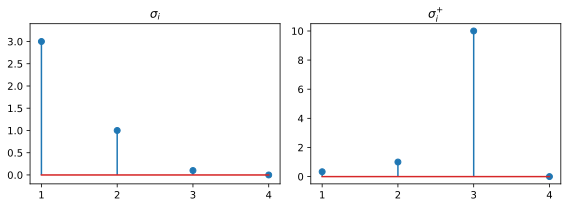

In [5]:
import numpy as np
import matplotlib.pyplot as plt

sigma = np.array([3.0, 1.0, 0.1, 0.0])
sigma_plus = np.zeros_like(sigma)
nz = sigma > 0
sigma_plus[nz] = 1.0 / sigma[nz]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.0))
x = np.arange(len(sigma))
axes[0].stem(x, sigma)
axes[0].set_title(r'$\sigma_i$')
axes[0].set_ylim(-0.2, 3.4)
axes[0].set_xticks(x); axes[0].set_xticklabels([f'{i}' for i in range(1, 5)])
axes[1].stem(x, sigma_plus)
axes[1].set_title(r'$\sigma_i^{+}$')
axes[1].set_xticks(x); axes[1].set_xticklabels([f'{i}' for i in range(1, 5)])
plt.tight_layout()
plt.show()


The right panel is the diagonal of $\boldsymbol{\Sigma}^{+}$. A small but positive singular value produces a large reciprocal (the price of near-singularity), but a *zero* singular value maps to zero. This is what distinguishes the pseudoinverse from a naive attempt to *divide by* $\boldsymbol{\Sigma}$: no division by zero occurs, because the zero directions are quietly discarded. The pseudoinverse is as stable as the underlying matrix allows.


## The pseudoinverse solves least squares

The pseudoinverse earns its keep by solving systems $\mathbf{A}\mathbf{x} = \mathbf{b}$ that have no solution or many. The claim: $\mathbf{x}^{+} = \mathbf{A}^{+}\mathbf{b}$ is the unique *minimum-norm least-squares* solution — it minimizes $\lVert\mathbf{A}\mathbf{x}-\mathbf{b}\rVert$ over all $\mathbf{x}$, and among all minimizers it has the smallest norm.

The proof is a rotation argument. Orthogonal matrices preserve norms, so with $\mathbf{z} = \mathbf{V}^{\mathsf T}\mathbf{x}$ and $\mathbf{c} = \mathbf{U}^{\mathsf T}\mathbf{b}$,

$$
\lVert\mathbf{A}\mathbf{x}-\mathbf{b}\rVert^2
= \lVert\boldsymbol{\Sigma}\mathbf{z}-\mathbf{c}\rVert^2
= \sum_{i=1}^{r}(\sigma_i z_i - c_i)^2 + \sum_{i=r+1}^{m} c_i^2 .
$$

The second sum is fixed; the first is minimized by $z_i = c_i/\sigma_i$ for $i\le r$, while $z_{r+1},\dots,z_n$ are free. All least-squares solutions are therefore $\mathbf{x} = \sum_{i\le r}(c_i/\sigma_i)\mathbf{v}_i + \sum_{i>r} z_i \mathbf{v}_i$. The trailing term is an arbitrary null-space direction, and it only adds norm, so the minimum-norm solution drops it: $\mathbf{x}^{+} = \sum_{i\le r}(c_i/\sigma_i)\mathbf{v}_i = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\mathsf T}\mathbf{b} = \mathbf{A}^{+}\mathbf{b}$. This one matrix therefore solves least-squares problems of every rank at once; its geometric form (rotate, invert nonzero scales, rotate back) was the content of Chapter 3.


**Minimum-norm least squares.** Two solutions with identical residual, one strictly smaller: the pseudoinverse returns the minimum-norm one.


In [6]:
import numpy as np

rng = np.random.default_rng(4)
m, n = 6, 4
U = np.linalg.qr(rng.standard_normal((m, m)))[0]
V = np.linalg.qr(rng.standard_normal((n, n)))[0]
sigma = np.array([2.0, 1.0, 0.0, 0.0])
A = (U[:, :n] * sigma) @ V.T          # rank 2
b = rng.standard_normal(m)

xplus  = np.linalg.pinv(A) @ b
nullv  = V[:, 2]                       # a null-space direction (sigma_3 = 0)
xshift = xplus + 2.0 * nullv

print("|| A xplus  - b || =", np.linalg.norm(A @ xplus - b))
print("|| A xshift - b || =", np.linalg.norm(A @ xshift - b))
print("|| xplus ||  =", np.linalg.norm(xplus))
print("|| xshift || =", np.linalg.norm(xshift))
print("xplus orthogonal to null(A):", np.abs(xplus @ nullv) < 1e-12)


|| A xplus  - b || = 1.9995439480969384
|| A xshift - b || = 1.9995439480969384
|| xplus ||  = 0.7156562360389209
|| xshift || = 2.1241854552231065
xplus orthogonal to null(A): True


The two vectors give the same residual (to round-off) because they differ only by a null-space direction, but $\mathbf{x}^{+}$ is the shorter of the two. The last line shows the defining property directly: the pseudoinverse solution is orthogonal to the null space, so it cannot contain any wasted component.


## Algebra of the pseudoinverse

The pseudoinverse obeys most of the inverse's algebra, with one notable failure.

| Identity | Holds? |
|---|---|
| $(\mathbf{A}^{+})^{+} = \mathbf{A}$ | yes |
| $(\mathbf{A}^{\mathsf T})^{+} = (\mathbf{A}^{+})^{\mathsf T}$ | yes |
| $(c\mathbf{A})^{+} = c^{-1}\mathbf{A}^{+}$ for $c\neq 0$ | yes |
| $\lVert\mathbf{A}^{+}\rVert_2 = 1/\sigma_r$ | yes |
| $\kappa(\mathbf{A}) = \lVert\mathbf{A}\rVert_2\lVert\mathbf{A}^{+}\rVert_2$ | yes |
| $(\mathbf{A}\mathbf{B})^{+} = \mathbf{B}^{+}\mathbf{A}^{+}$ | **no**, in general |

The last row is the departure from the inverse, where $(\mathbf{A}\mathbf{B})^{-1} = \mathbf{B}^{-1}\mathbf{A}^{-1}$ holds unconditionally. The pseudoinverse reverses order only under extra hypotheses (for example, when $\mathbf{A}$ has full column rank and $\mathbf{B}$ full row rank). The norm identity ties back to Chapter 3: $\kappa(\mathbf{A}) = \sigma_1/\sigma_r$ is the condition number, and since $\lVert\mathbf{A}^{+}\rVert_2 = 1/\sigma_r$, the formula $\kappa = \lVert\mathbf{A}\rVert_2\lVert\mathbf{A}^{+}\rVert_2$ packages it as a product of operator norms. The pseudoinverse also swaps the four subspaces: $\mathcal{C}(\mathbf{A}^{+}) = \mathcal{C}(\mathbf{A}^{\mathsf T})$, $N(\mathbf{A}^{+}) = N(\mathbf{A}^{\mathsf T})$, and their transposes — the same interchange the SVD performs between left and right singular vectors.


**Pseudoinverse identities.** The identities that hold, verified numerically; and the order-reversal identity that fails.


In [7]:
import numpy as np

rng = np.random.default_rng(5)
A = rng.standard_normal((5, 4))
Aplus = np.linalg.pinv(A)

print("(A+)+ == A           :", np.allclose(np.linalg.pinv(Aplus), A))
print("(A.T)+ == (A+).T     :", np.allclose(np.linalg.pinv(A.T), Aplus.T))

s = np.linalg.svd(A, compute_uv=False)
print("||A+||_2 == 1/sigma_min :", np.allclose(np.linalg.norm(Aplus, 2), 1.0 / s[-1]))
print("kappa == ||A|| ||A+||    :",
      np.allclose(s[0] / s[-1], np.linalg.norm(A, 2) * np.linalg.norm(Aplus, 2)))

B = rng.standard_normal((4, 3))
print("(AB)+ == B+ A+        :",
      np.allclose(np.linalg.pinv(A @ B), np.linalg.pinv(B) @ np.linalg.pinv(A)))


(A+)+ == A           : True
(A.T)+ == (A+).T     : True
||A+||_2 == 1/sigma_min : True
kappa == ||A|| ||A+||    : True
(AB)+ == B+ A+        : False


The first four lines confirm the identities; the last prints `False`, the general failure of $(\mathbf{A}\mathbf{B})^{+} = \mathbf{B}^{+}\mathbf{A}^{+}$. This is a genuine algebraic distinction, not a numerical artifact — it is why the pseudoinverse is not a drop-in replacement for the inverse.


## Summary

The chapter assembled a single object that answers every invertibility question. For a square full-rank matrix, $\mathbf{A}^{-1} = \mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{U}^{\mathsf T}$; for a tall or wide full-rank matrix, the same formula restricted to the nonzero singular values gives the one-sided inverse; for everything else it gives the Moore–Penrose pseudoinverse $\mathbf{A}^{+} = \mathbf{V}\boldsymbol{\Sigma}^{+}\mathbf{U}^{\mathsf T}$, the unique matrix satisfying the four Penrose conditions. Three practical lessons: never form an inverse just to solve a system; the pseudoinverse turns a zero singular value into zero, not infinity; and $\mathbf{x}^{+} = \mathbf{A}^{+}\mathbf{b}$ is always the minimum-norm least-squares solution, which the next two chapters will put to work in projection and least-squares problems.


## Problems

Each problem builds on the SVD recipes for the inverse, the one-sided inverses, and the pseudoinverse. Problems 1–2 are theory, 3–4 are short numerical checks, and Problem 5 is a numerical experiment.


### Problem 1 — The inverse's singular values

Let $\mathbf{A}\in\mathbb{R}^{n\times n}$ be invertible with singular values $\sigma_1\ge\cdots\ge\sigma_n>0$.

(a) From $\mathbf{A}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{\mathsf T}$, derive the SVD of $\mathbf{A}^{-1}$ and show that its singular values are $\sigma_n^{-1}\ge\cdots\ge\sigma_1^{-1}$, the reciprocals in reverse order.

(b) Conclude $\lVert\mathbf{A}^{-1}\rVert_2=1/\sigma_n$.

(c) Prove $\kappa(\mathbf{A})=\lVert\mathbf{A}\rVert_2\lVert\mathbf{A}^{-1}\rVert_2=\sigma_1/\sigma_n$.


### Problem 2 — When the pseudoinverse reverses order

Let $\mathbf{A}\in\mathbb{R}^{m\times n}$ have full column rank and $\mathbf{B}\in\mathbb{R}^{n\times p}$ have full row rank.

(a) Show that $\mathbf{A}^{+}\mathbf{A}=\mathbf{I}_n$ and $\mathbf{B}\mathbf{B}^{+}=\mathbf{I}_n$.

(b) Verify the four Penrose conditions for $\mathbf{B}^{+}\mathbf{A}^{+}$ as a candidate for $(\mathbf{A}\mathbf{B})^{+}$, using part (a) and the symmetry of the projectors $\mathbf{A}\mathbf{A}^{+}$ and $\mathbf{B}^{+}\mathbf{B}$.

(c) Conclude $(\mathbf{A}\mathbf{B})^{+}=\mathbf{B}^{+}\mathbf{A}^{+}$ under these hypotheses, and state why the identity fails in general.


### Problem 3 — The SVD inverse

Build a symmetric positive definite matrix, reconstruct $\mathbf{A}^{-1}$ from its SVD as $\mathbf{V}\boldsymbol{\Sigma}^{-1}\mathbf{U}^{\mathsf T}$, and compare against `np.linalg.inv`. The starter code below also prints the singular values of $\mathbf{A}^{-1}$, which should be the reciprocals of those of $\mathbf{A}$ in reverse order.


In [1]:
import numpy as np

rng = np.random.default_rng(0)
n = 5
A = rng.standard_normal((n, n))
A = A @ A.T + n * np.eye(n)

U, s, Vt = np.linalg.svd(A)
Ainv_svd = (Vt.T / s) @ U.T

print('|| A Ainv_svd - I ||      =', np.linalg.norm(A @ Ainv_svd - np.eye(n)))
print('|| Ainv_svd - inv(A) ||   =', np.linalg.norm(Ainv_svd - np.linalg.inv(A)))
print('singular values of A^-1   =', np.sort(1.0 / s)[::-1])


The two routes agree to machine precision. The printed singular values of $\mathbf{A}^{-1}$ are the reciprocals of those of $\mathbf{A}$ in reverse order, so the largest is $1/\sigma_n$, the amplification factor when solving $\mathbf{A}\mathbf{x}=\mathbf{b}$.


### Problem 4 — Minimum-norm least squares

Build a rank-2 $6\times4$ system $\mathbf{A}\mathbf{x}=\mathbf{b}$, compute $\mathbf{x}^{+}=\mathbf{A}^{+}\mathbf{b}$, and compare it with a solution shifted by a null-space direction. The starter code below prints both residuals, both norms, and the orthogonality check.


In [1]:
import numpy as np

rng = np.random.default_rng(4)
m, n = 6, 4
U = np.linalg.qr(rng.standard_normal((m, m)))[0]
V = np.linalg.qr(rng.standard_normal((n, n)))[0]
sigma = np.array([2.0, 1.0, 0.0, 0.0])
A = (U[:, :n] * sigma) @ V.T
b = rng.standard_normal(m)

xplus = np.linalg.pinv(A) @ b
nullv = V[:, 2]
xshift = xplus + 2.0 * nullv

print('|| A xplus  - b || =', np.linalg.norm(A @ xplus - b))
print('|| A xshift - b || =', np.linalg.norm(A @ xshift - b))
print('|| xplus ||  =', np.linalg.norm(xplus))
print('|| xshift || =', np.linalg.norm(xshift))
print('xplus orthogonal to null(A):', np.abs(xplus @ nullv) < 1e-12)


The two vectors give the same residual to round-off because they differ only by a null-space direction, but $\mathbf{x}^{+}$ is strictly shorter. The last line shows the defining property directly: the pseudoinverse solution is orthogonal to the null space, so it carries no wasted component.


### Problem 5 — The pseudoinverse identities

**Challenge.** Verify the algebra table of the chapter numerically, including the one identity that fails.

(a) For a random $5\times4$ matrix (fixed seed), verify $(\mathbf{A}^{+})^{+}=\mathbf{A}$, $(\mathbf{A}^{\mathsf T})^{+}=(\mathbf{A}^{+})^{\mathsf T}$, $(c\mathbf{A})^{+}=c^{-1}\mathbf{A}^{+}$, $\lVert\mathbf{A}^{+}\rVert_2=1/\sigma_r$, and $\kappa(\mathbf{A})=\lVert\mathbf{A}\rVert_2\lVert\mathbf{A}^{+}\rVert_2$.

(b) For random $\mathbf{A}\in\mathbb{R}^{5\times4}$ and $\mathbf{B}\in\mathbb{R}^{4\times3}$, quantify the failure of $(\mathbf{A}\mathbf{B})^{+}=\mathbf{B}^{+}\mathbf{A}^{+}$ by the norm of the difference.

(c) Construct full-rank $\mathbf{A}\in\mathbb{R}^{6\times3}$ and $\mathbf{B}\in\mathbb{R}^{3\times5}$ and verify that the identity holds.

(d) On a rank-deficient matrix, verify the four Penrose conditions for $\mathbf{A}^{+}$. The starter code below runs all four parts.


In [1]:
import numpy as np

rng = np.random.default_rng(5)

A = rng.standard_normal((5, 4))
Aplus = np.linalg.pinv(A)
s = np.linalg.svd(A, compute_uv=False)
c = 2.5

print('(a) (A+)+ == A          :', np.allclose(np.linalg.pinv(Aplus), A))
print('(a) (A.T)+ == (A+).T    :', np.allclose(np.linalg.pinv(A.T), Aplus.T))
print('(a) (cA)+ == A+/c       :', np.allclose(np.linalg.pinv(c * A), Aplus / c))
print('(a) ||A+|| == 1/s_r     :', np.allclose(np.linalg.norm(Aplus, 2), 1.0 / s[-1]))
print('(a) kappa == ||A||||A+|| :', np.allclose(s[0] / s[-1],
                                                np.linalg.norm(A, 2) * np.linalg.norm(Aplus, 2)))

B = rng.standard_normal((4, 3))
gap = np.linalg.norm(np.linalg.pinv(A @ B) - np.linalg.pinv(B) @ np.linalg.pinv(A))
print('(b) ||(AB)+ - B+ A+||   =', f'{gap:.3e}')

At = rng.standard_normal((6, 3))
Bt = rng.standard_normal((3, 5))
print('(c) (AB)+ == B+ A+      :', np.allclose(np.linalg.pinv(At @ Bt),
                                               np.linalg.pinv(Bt) @ np.linalg.pinv(At)))

Ad = np.zeros((5, 4))
Ad[:, :2] = rng.standard_normal((5, 2))
Adp = np.linalg.pinv(Ad)
print('(d) A A+ A == A         :', np.allclose(Ad @ Adp @ Ad, Ad))
print('(d) A+ A A+ == A+       :', np.allclose(Adp @ Ad @ Adp, Adp))
print('(d) (A A+) symmetric    :', np.allclose(Ad @ Adp, (Ad @ Adp).T))
print('(d) (A+ A) symmetric    :', np.allclose(Adp @ Ad, (Adp @ Ad).T))


Parts (a), (c), and (d) all print `True`; part (b) prints a nonzero gap, the general failure of $(\mathbf{A}\mathbf{B})^{+}=\mathbf{B}^{+}\mathbf{A}^{+}$. This is a genuine algebraic distinction, not a numerical artifact: the pseudoinverse reverses order only under extra hypotheses such as full column and row rank.
